# R21 experiment: ordinary association versus a structural causal model

A supervised synthetic train/test benchmark with known ground-truth mechanisms.

## tl;dr

This experiment answers the intended question directly.

Under strong renal biomarker distortion:

- **Biomarker-only logistic regression:** 76.72%
  accuracy and 37.03% false atrial
  classification in the renal/competing subgroup.
- **Structural causal model:** 81.17% accuracy and
  13.51% false atrial classification.
- **Kidney-adjusted logistic regression:** 81.16%
  accuracy and 13.55% false atrial
  classification.

Therefore, the SCM **does beat an ordinary biomarker-only associative
classifier**, but it **does not beat an associative classifier once kidney
status is included**. The SCM-minus-adjusted-logistic accuracy difference was
only 0.005 percentage points
(95% CI -0.013 to
0.023).

## Context & Methods

### The models in plain English

1. **Biomarker-only logistic regression** learns which biomarker patterns are associated with the atrial label. It has no causal diagram.
2. **Kidney-adjusted logistic regression** is the same ordinary classifier with kidney status added. It is the fairness control.
3. **Structural causal model** represents kidney → NT-proBNP-like and mechanism → biomarker paths, then switches candidate mechanisms off or on to calculate disablement and sufficiency.

Every repeat uses 3,000 training patients and a new 1,000-patient test cohort. All models use the same paired data. The full methods and interpretation boundary are in `R21_PRELIMINARY_METHODOLOGY.md`.

In [1]:
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

from r21_associative_vs_scm import (
    ASSOCIATIVE_ADJUSTED,
    ASSOCIATIVE_BIOMARKERS,
    SCM_COUNTERFACTUAL,
    ComparisonConfig,
    run_full_comparison,
)

CONFIG = ComparisonConfig()
OUTPUT_DIR = Path.cwd() / 'outputs_associative_vs_scm'
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
asdict(CONFIG)

{'seed': 20260729,
 'training_patients': 3000,
 'test_patients': 1000,
 'repeats_per_level': 500,
 'confounding_strengths_sd': (0.0, 0.75, 1.5, 2.25),
 'confounding_labels': ('None\n(0 SD)',
  'Weak\n(0.75 SD)',
  'Moderate\n(1.50 SD)',
  'Strong\n(2.25 SD)'),
 'logistic_l2_penalty': 1.0,
 'logistic_max_iter': 50,
 'logistic_tolerance': 1e-08,
 'scm_prior_smoothing': 0.5,
 'variance_floor': 1e-06,
 'counterfactual_disablement_weight': 0.5,
 'counterfactual_sufficiency_weight': 0.5}

## Data

The next cell regenerates all 2,000 paired train/test experiments and overwrites only files inside `outputs_associative_vs_scm/`.

In [2]:
artifacts = run_full_comparison(CONFIG, OUTPUT_DIR)
print(f"Saved results to {OUTPUT_DIR.resolve()}")

Saved results to /Users/neeamhayder/Documents/ESUS Endotyping with Causal Models/outputs_associative_vs_scm


### Validation checks

In [3]:
raw = artifacts['raw_metrics']
summary = artifacts['summary']
fits = artifacts['fit_diagnostics']

assert len(raw) == 4 * 500 * 3 * 2
assert raw.groupby(['strength_index', 'method', 'metric']).size().eq(500).all()
assert raw['value'].between(0, 1).all()
assert fits['biomarkers_only_converged'].all()
assert fits['adjusted_converged'].all()
assert fits['maximum_counterfactual_posterior_difference'].max() < 1e-12
assert summary[['ci_low', 'mean', 'ci_high']].apply(
    lambda row: row['ci_low'] <= row['mean'] <= row['ci_high'], axis=1
).all()
print('All row-count, range, convergence, CI, and SCM invariance checks passed.')

All row-count, range, convergence, CI, and SCM invariance checks passed.


## Results

### Figure P1

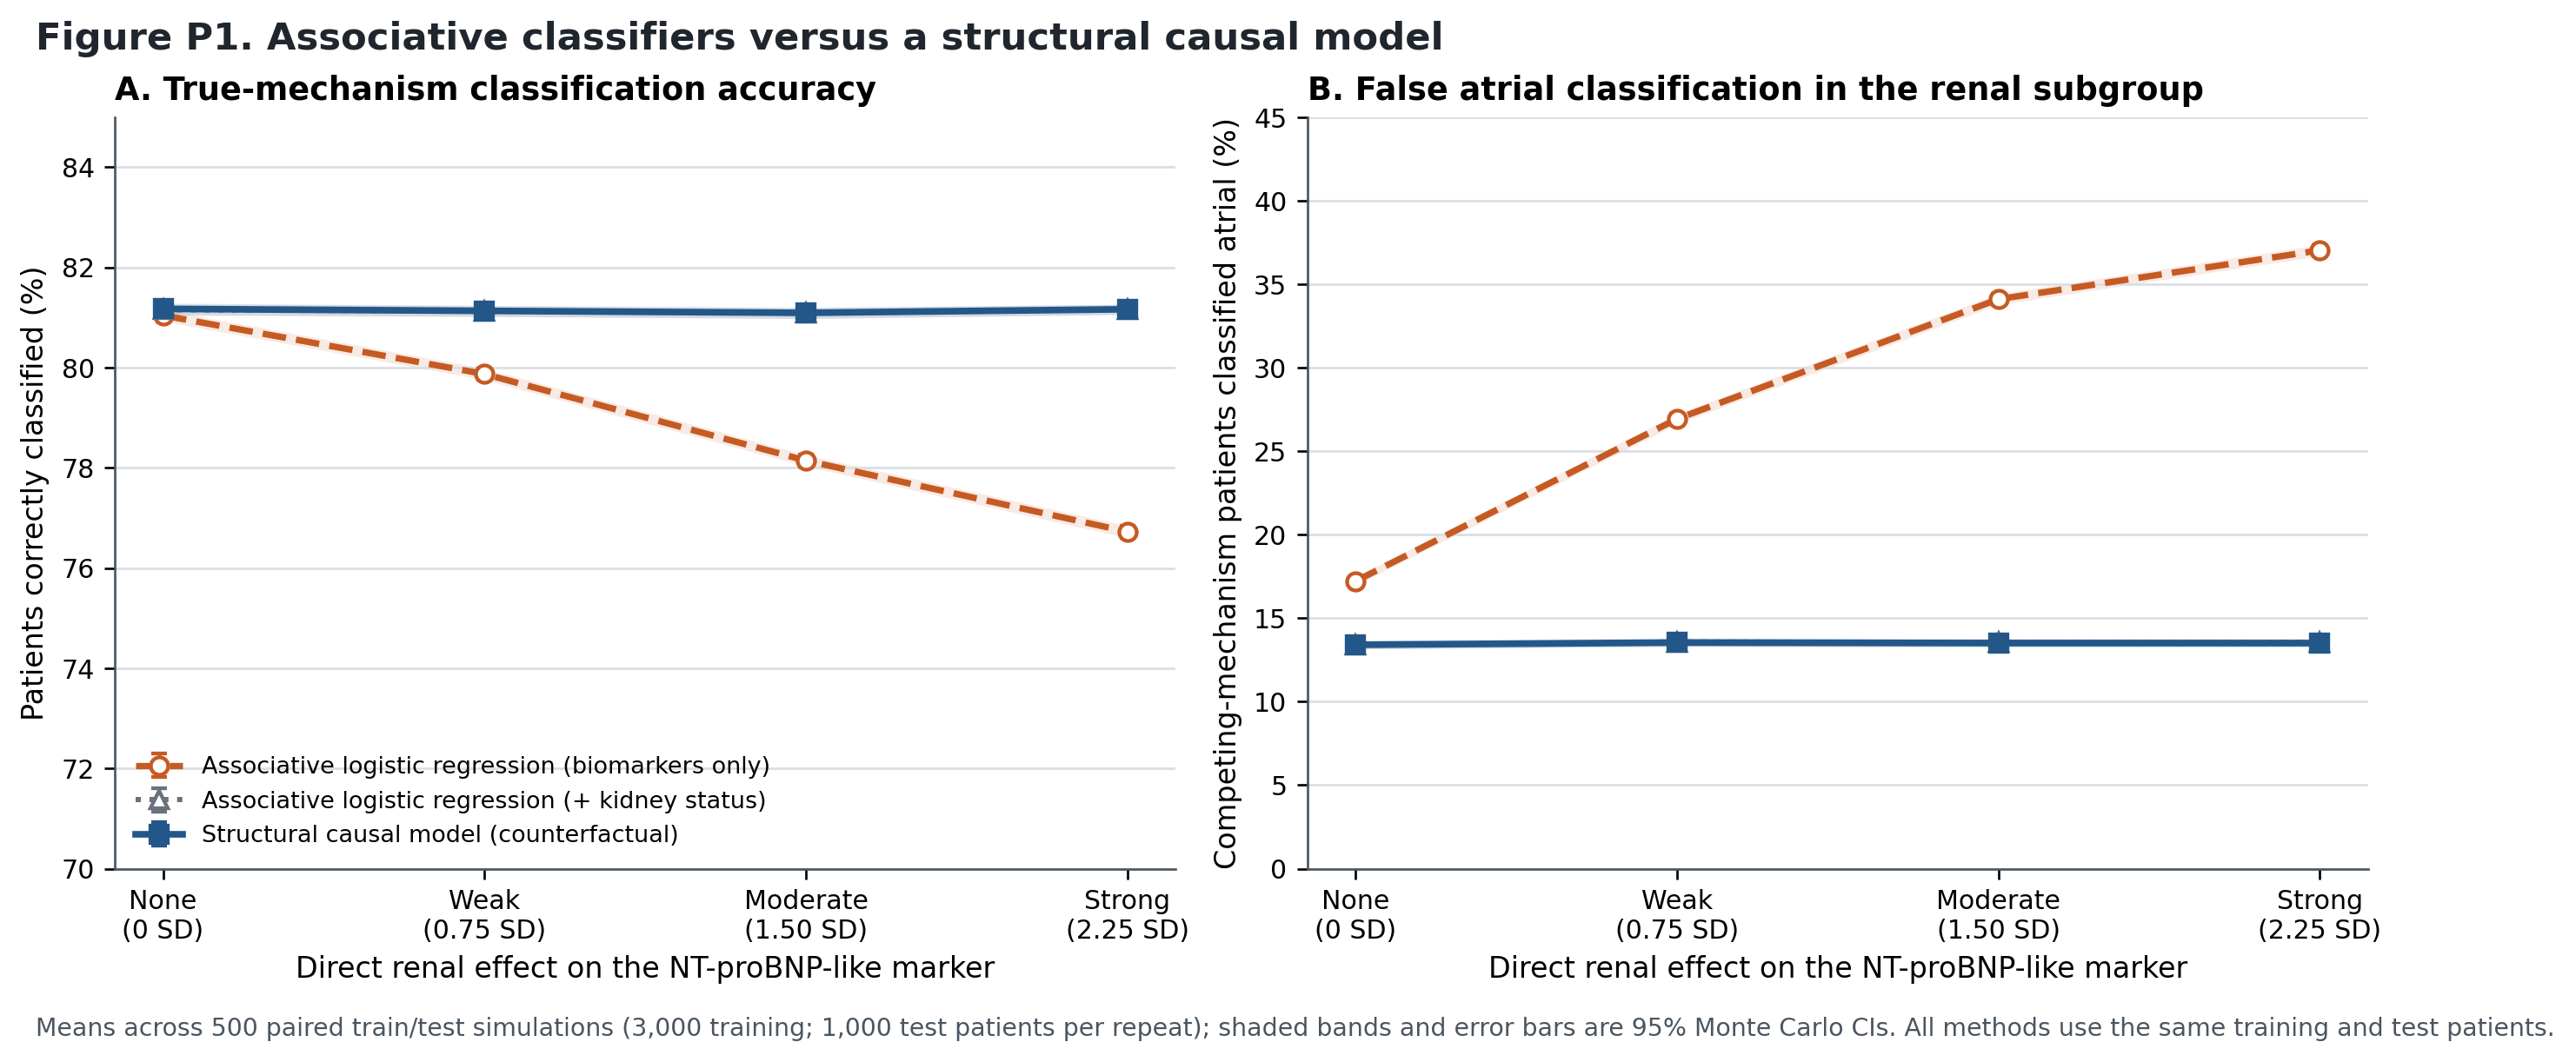

In [4]:
display(Image(filename=str(artifacts['figure_png']), width=1150))

### Exact estimates

In [5]:
result_table = summary[[
    'renal_effect_sd', 'method', 'metric', 'n_repeats',
    'mean', 'ci_low', 'ci_high', 'repeat_q025', 'repeat_q975'
]].copy()
for column in ['mean', 'ci_low', 'ci_high', 'repeat_q025', 'repeat_q975']:
    result_table[column] = (100 * result_table[column]).round(3)
display(result_table)

,renal_effect_sd,method,metric,n_repeats,mean,ci_low,ci_high,repeat_q025,repeat_q975
0,0.00,Associative logistic regression (+ kidney status),false_atrial_confounded_competing,500,13.403,13.147,13.660,8.017,19.477
1,0.00,Associative logistic regression (+ kidney status),true_mechanism_accuracy,500,81.156,81.041,81.271,78.495,83.600
2,0.00,Associative logistic regression (biomarkers only),false_atrial_confounded_competing,500,17.216,16.960,17.472,11.392,22.817
3,0.00,Associative logistic regression (biomarkers only),true_mechanism_accuracy,500,81.042,80.928,81.156,78.448,83.352
4,0.00,Structural causal model (counterfactual),false_atrial_confounded_competing,500,13.406,13.154,13.657,7.830,19.428
5,0.00,Structural causal model (counterfactual),true_mechanism_accuracy,500,81.174,81.059,81.289,78.400,83.600
6,0.75,Associative logistic regression (+ kidney status),false_atrial_confounded_competing,500,13.570,13.325,13.815,8.696,19.188
7,0.75,Associative logistic regression (+ kidney status),true_mechanism_accuracy,500,81.128,81.019,81.238,78.800,83.600
8,0.75,Associative logistic regression (biomarkers only),false_atrial_confounded_competing,500,26.930,26.625,27.235,20.799,33.626
9,0.75,Associative logistic regression (biomarkers only),true_mechanism_accuracy,500,79.872,79.758,79.986,77.448,82.552


### Paired model contrasts

In [6]:
contrasts = artifacts['paired_contrasts'].copy()
for column in ['mean_difference', 'ci_low', 'ci_high']:
    contrasts[column] = (100 * contrasts[column]).round(3)
display(contrasts)

,strength_index,renal_effect_sd,metric,contrast,n_repeats,mean_difference,ci_low,ci_high
0,0,0.00,false_atrial_confounded_competing,associative_minus_scm_biomarkers_only,500,3.811,3.658,3.963
1,0,0.00,false_atrial_confounded_competing,associative_minus_scm_kidney_adjusted,500,-0.002,-0.052,0.047
2,0,0.00,true_mechanism_accuracy,scm_minus_biomarkers_only,500,0.132,0.088,0.176
3,0,0.00,true_mechanism_accuracy,scm_minus_kidney_adjusted,500,0.018,-0.001,0.036
4,1,0.75,false_atrial_confounded_competing,associative_minus_scm_biomarkers_only,500,13.393,13.136,13.650
5,1,0.75,false_atrial_confounded_competing,associative_minus_scm_kidney_adjusted,500,0.033,-0.016,0.083
6,1,0.75,true_mechanism_accuracy,scm_minus_biomarkers_only,500,1.262,1.183,1.340
7,1,0.75,true_mechanism_accuracy,scm_minus_kidney_adjusted,500,0.006,-0.011,0.022
8,2,1.50,false_atrial_confounded_competing,associative_minus_scm_biomarkers_only,500,20.593,20.317,20.869
9,2,1.50,false_atrial_confounded_competing,associative_minus_scm_kidney_adjusted,500,0.038,-0.016,0.093


## Takeaways

1. The SCM is more robust than a biomarker-only associative classifier when kidney dysfunction produces misleading atrial biomarker elevation.
2. Kidney-adjusted logistic regression matches the SCM in this simple linear, correctly specified, same-distribution benchmark.
3. The result therefore supports explicit renal adjustment, not a general claim that counterfactual classification is more accurate than association.
4. This is supervised classification with known synthetic labels. It is not yet an unsupervised endotype-discovery experiment.